In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
foods = pd.read_csv('../data/processed/foods_cleaned.csv')

<Figure size 1200x800 with 0 Axes>

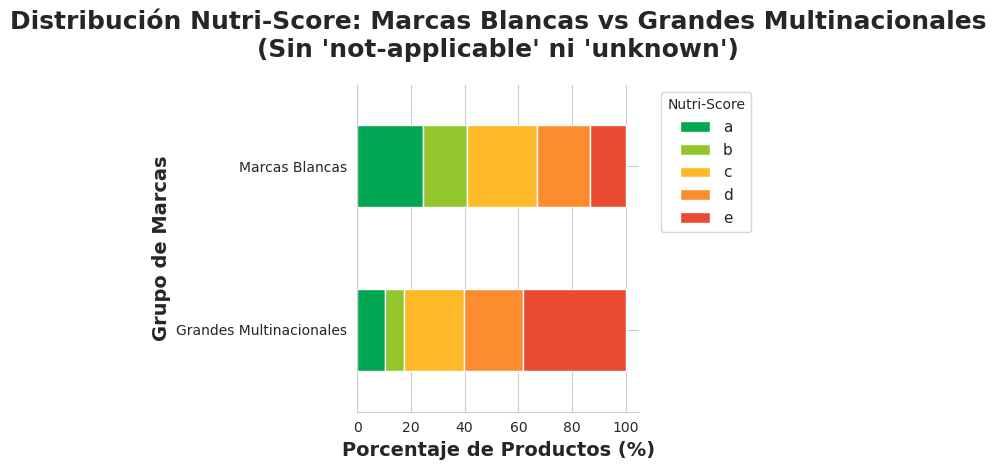

Productos válidos (sin not-applicable/unknown):
grupo
Marcas Blancas             1184
Grandes Multinacionales     767
Name: count, dtype: int64

Distribución %:
nutriscore_grade            a     b     c     d     e
grupo                                                
Grandes Multinacionales  10.2   7.2  22.6  21.8  38.3
Marcas Blancas           24.4  16.4  26.2  19.6  13.4


In [4]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


# 1. Listas de grupos
marcas_blancas = [
    'hacendado', 'mercadona', 'deliplus', 'compy', 'bosque verde', 'entrepinares', 
    'lidl', 'alesto', 'milbona', 'fin carré', 'sondey', 'freshona', 'crownfield', 
    'carrefour', 'u bio', 'paturages', 'nos regions ont du talent',
    'bio village', 'marque repère',
    'aldi', 'harvest morn', 'village bakery',
    'tesco', 'auchan', 'intermarche'
]

grandes_multinacionales = [
    'nestle', 'nescafe', 'unilever', 'hellmann', 'knorr', 'mondelez', 'lu', 'milka', 
    'danone', 'activia', 'ferrero', 'nutella', 'pepsico', 'lays', 'coca-cola', 
    'kellogg', 'pringles', 'heinz', 'mars', 'dr. oetker'
]

# 2. Clasificar
foods['brands_clean'] = foods['brands'].fillna('').astype(str).str.lower()
def clasificar_grupo(brand):
    brands_list = brand.split()
    for b in brands_list:
        if any(mb in b for mb in marcas_blancas):
            return 'Marcas Blancas'
        if any(multi in b for multi in grandes_multinacionales):
            return 'Grandes Multinacionales'
    return 'Otras'

foods['grupo'] = foods['brands_clean'].apply(clasificar_grupo)

# 3. Filtrar: QUITAR not-applicable, unknown + datos válidos
df_plot = foods[
    (foods['nutriscore_grade'].notna()) &
    (foods['nutriscore_grade'].isin(['a', 'b', 'c', 'd', 'e'])) &  # ← SIN not-applicable/unknown
    (foods['grupo'].isin(['Marcas Blancas', 'Grandes Multinacionales']))
].copy()

# 4. % distribución
nutri_dist = df_plot.groupby(['grupo', 'nutriscore_grade']).size().unstack(fill_value=0)
nutri_pct = nutri_dist.div(nutri_dist.sum(axis=1), axis=0) * 100

# 5. BAR PLOT
plt.figure(figsize=(12, 8))
sns.set_style("whitegrid")

colors_nutri = {'a': '#00A651', 'b': '#93C52D', 'c': '#FDB927', 'd': '#FD8C2E', 'e': '#E94B32'}
nutri_order = ['a', 'b', 'c', 'd', 'e']

nutri_pct[nutri_order].plot(kind='barh', stacked=True, color=[colors_nutri[col] for col in nutri_order])

plt.title("Distribución Nutri-Score: Marcas Blancas vs Grandes Multinacionales\n(Sin 'not-applicable' ni 'unknown')", 
          fontsize=18, fontweight='bold', pad=20)
plt.xlabel("Porcentaje de Productos (%)", fontsize=14, fontweight='bold')
plt.ylabel("Grupo de Marcas", fontsize=14, fontweight='bold')
plt.legend(title="Nutri-Score", bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=11)
plt.xticks(rotation=0)
sns.despine()
plt.tight_layout()
plt.show()

# Resumen
print("Productos válidos (sin not-applicable/unknown):")
print(df_plot['grupo'].value_counts())
print("\nDistribución %:")
print(nutri_pct.round(1))

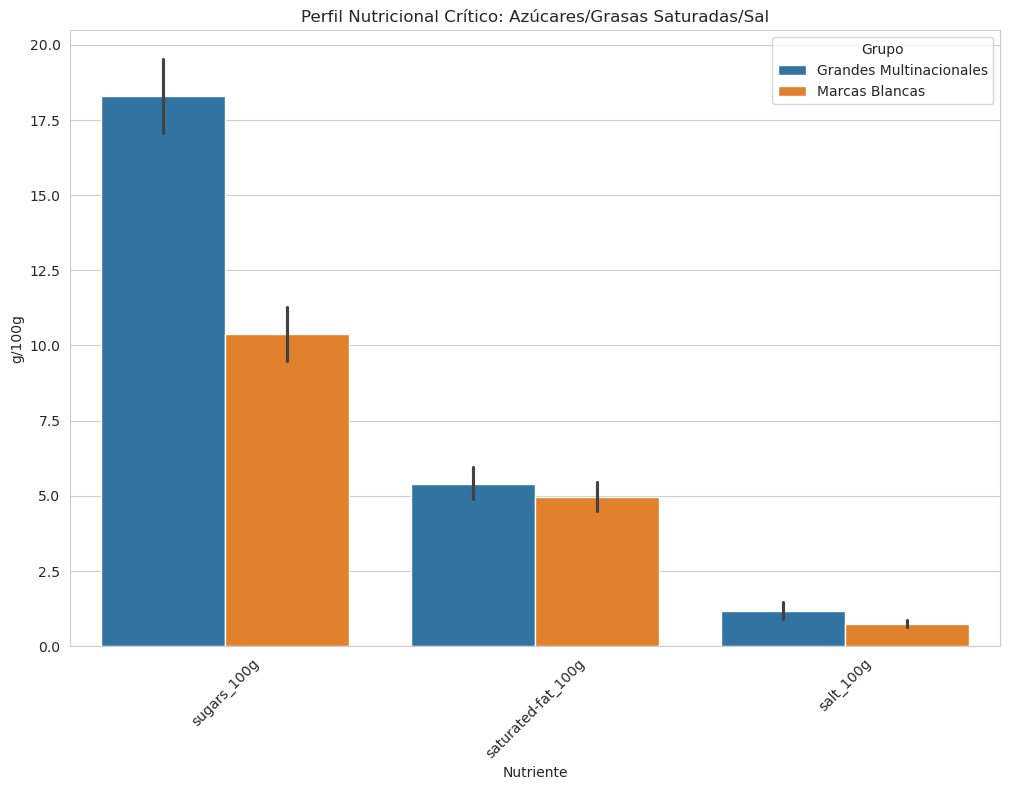

In [5]:
nutri_cols = ['sugars_100g', 'saturated-fat_100g', 'salt_100g']
df_melt = df_plot.melt(id_vars='grupo', value_vars=nutri_cols, 
                       var_name='Nutriente', value_name='g_100g')

plt.figure(figsize=(12, 8))
sns.barplot(data=df_melt, x='Nutriente', y='g_100g', hue='grupo')
plt.title("Perfil Nutricional Crítico: Azúcares/Grasas Saturadas/Sal")
plt.ylabel("g/100g")
plt.xticks(rotation=45)
plt.legend(title="Grupo")
plt.show()

<Figure size 1200x800 with 0 Axes>

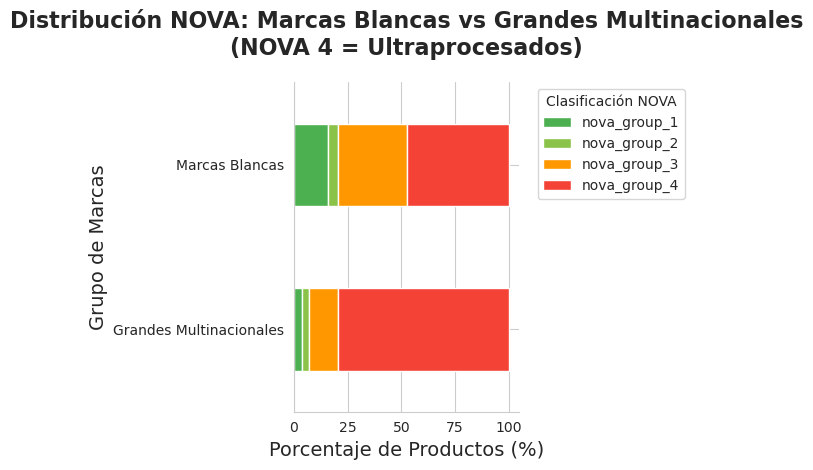

Distribución NOVA (%):
nova_group               nova_group_1  nova_group_2  nova_group_3  \
grupo                                                               
Grandes Multinacionales           3.6           3.2          13.9   
Marcas Blancas                   16.0           4.4          32.4   

nova_group               nova_group_4  
grupo                                  
Grandes Multinacionales          79.3  
Marcas Blancas                   47.2  

Total productos válidos NOVA: 1908
Por grupo:
grupo
Marcas Blancas             1160
Grandes Multinacionales     748
Name: count, dtype: int64


In [6]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Clasificación grupos
marcas_blancas = [
    'hacendado', 'mercadona', 'deliplus', 'compy', 'bosque verde', 'entrepinares', 
    'lidl', 'alesto', 'milbona', 'fin carré', 'sondey', 'freshona', 'crownfield', 
    'carrefour', 'u bio', 'paturages', 'nos regions ont du talent',
    'bio village', 'marque repère',
    'aldi', 'harvest morn', 'village bakery',
    'tesco', 'auchan', 'intermarche'
]

grandes_multinacionales = [
    'nestle', 'nescafe', 'unilever', 'hellmann', 'knorr', 'mondelez', 'lu', 'milka', 
    'danone', 'activia', 'ferrero', 'nutella', 'pepsico', 'lays', 'coca-cola', 
    'kellogg', 'pringles', 'heinz', 'mars', 'dr. oetker'
]

foods['brands_clean'] = foods['brands'].fillna('').astype(str).str.lower()

def clasificar_grupo(brand):
    brands_list = brand.split()
    for b in brands_list:
        if any(mb in b for mb in marcas_blancas):
            return 'Marcas Blancas'
        if any(multi in b for multi in grandes_multinacionales):
            return 'Grandes Multinacionales'
    return 'Otras'

foods['grupo'] = foods['brands_clean'].apply(clasificar_grupo)

# ✅ CORRECCIÓN: Filtrar valores válidos de nova_group (debe ser 1-4)
df_plot = foods[
    (foods['nova_group'].between(1, 4)) &  # Valores NOVA válidos
    (foods['grupo'].isin(['Marcas Blancas', 'Grandes Multinacionales']))
].copy()

# Convertir nova_group a string para mejor visualización
df_plot['nova_group'] = 'nova_group_' + df_plot['nova_group'].astype(str)

# Calcular % distribución NOVA
dist_nova = df_plot.groupby(['grupo', 'nova_group']).size().unstack(fill_value=0)
dist_pct = dist_nova.div(dist_nova.sum(axis=1), axis=0) * 100

# Asegurar que todas las categorías NOVA 1-4 estén presentes
for i in range(1, 5):
    col = f'nova_group_{i}'
    if col not in dist_pct.columns:
        dist_pct[col] = 0

# Ordenar columnas
dist_pct = dist_pct[[f'nova_group_{i}' for i in range(1, 5)]]

# GRÁFICO: Distribución NOVA por grupo
plt.figure(figsize=(12, 8))
sns.set_style("whitegrid")
colors_nova = {'nova_group_1': '#4CAF50', 'nova_group_2': '#8BC34A', 
               'nova_group_3': '#FF9800', 'nova_group_4': '#F44336'}

dist_pct.plot(kind='barh', stacked=True, 
              color=[colors_nova.get(col, '#9E9E9E') for col in dist_pct.columns])
plt.title("Distribución NOVA: Marcas Blancas vs Grandes Multinacionales\n(NOVA 4 = Ultraprocesados)", 
          fontsize=16, fontweight='bold', pad=20)
plt.xlabel("Porcentaje de Productos (%)", fontsize=14)
plt.ylabel("Grupo de Marcas", fontsize=14)
plt.legend(title="Clasificación NOVA", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=0)
sns.despine()
plt.tight_layout()
plt.show()

# TABLA RESUMEN
print("Distribución NOVA (%):")
print(dist_pct.round(1))
print(f"\nTotal productos válidos NOVA: {len(df_plot)}")
print("Por grupo:")
print(df_plot['grupo'].value_counts())

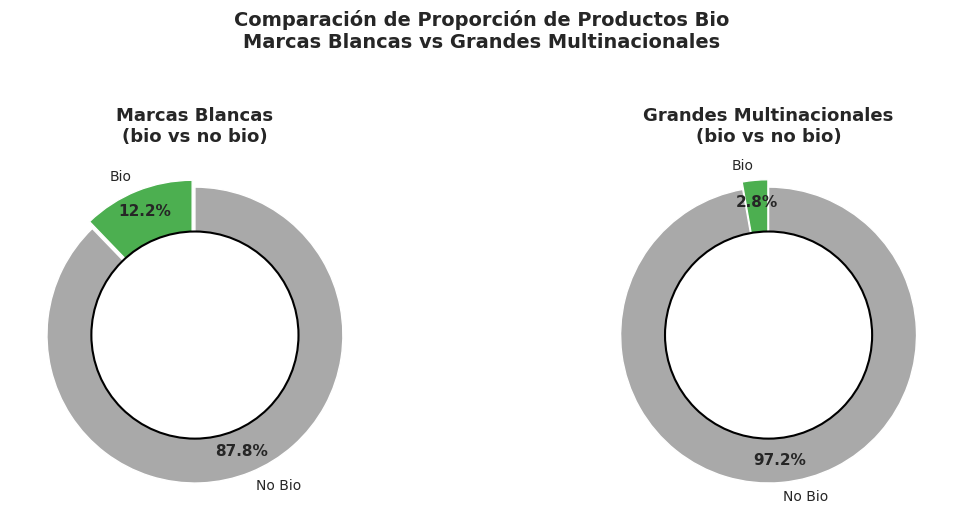

In [7]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Clasificación grupos (mismo diccionario)
marcas_blancas = ['hacendado', 'mercadona', 'deliplus', 'compy', 'bosque verde', 
                  'entrepinares', 'lidl', 'alesto', 'milbona', 'fin carré', 'sondey', 
                  'freshona', 'crownfield', 'carrefour', 'u bio', 'paturages', 
                  'nos regions ont du talent', 'bio village', 'marque repère', 
                  'aldi', 'harvest morn', 'village bakery', 'tesco', 'auchan', 'intermarche']

grandes_multinacionales = ['nestle', 'nescafe', 'unilever', 'hellmann', 'knorr', 
                           'mondelez', 'lu', 'milka', 'danone', 'activia', 'ferrero', 
                           'nutella', 'pepsico', 'lays', 'coca-cola', 'kellogg', 
                           'pringles', 'heinz', 'mars', 'dr. oetker']

foods['brands_clean'] = foods['brands'].fillna('').astype(str).str.lower()

def clasificar_grupo(brand):
    brands_list = brand.split()
    for b in brands_list:
        if any(mb in b for mb in marcas_blancas):
            return 'Marcas Blancas'
        if any(multi in b for multi in grandes_multinacionales):
            return 'Grandes Multinacionales'
    return 'Otras'

foods['grupo'] = foods['brands_clean'].apply(clasificar_grupo)

# Filtrar solo los dos grupos de interés
df_bio = foods[foods['grupo'].isin(['Marcas Blancas', 'Grandes Multinacionales'])].copy()

# GRÁFICO DE ANILLO (DONUT) - Solo para comparar proporciones de bio
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, grupo in zip(axes, ['Marcas Blancas', 'Grandes Multinacionales']):
    datos_grupo = df_bio[df_bio['grupo'] == grupo]['is_bio'].value_counts()
    bio_count = datos_grupo.get(True, 0)
    no_bio_count = datos_grupo.get(False, 0)
    
    sizes = [bio_count, no_bio_count]
    labels = ['Bio', 'No Bio']
    colors_donut = ['#4CAF50', '#A9A9A9']
    explode = (0.05, 0)
    
    wedges, texts, autotexts = ax.pie(sizes, explode=explode, labels=labels, colors=colors_donut,
                                        autopct='%1.1f%%', startangle=90, pctdistance=0.85)
    
    # Convertir a donut
    centre_circle = plt.Circle((0,0), 0.70, fc='white', linewidth=1.5, edgecolor='black')
    ax.add_artist(centre_circle)
    
    ax.set_title(f'{grupo}\n(bio vs no bio)', fontsize=13, fontweight='bold')
    
    # Aumentar tamaño de texto
    for autotext in autotexts:
        autotext.set_fontsize(11)
        autotext.set_fontweight('bold')
    for text in texts:
        text.set_fontsize(10)

plt.suptitle('Comparación de Proporción de Productos Bio\nMarcas Blancas vs Grandes Multinacionales', 
             fontsize=14, fontweight='bold', y=1.05)
plt.tight_layout()
plt.show()



<Figure size 1200x800 with 0 Axes>

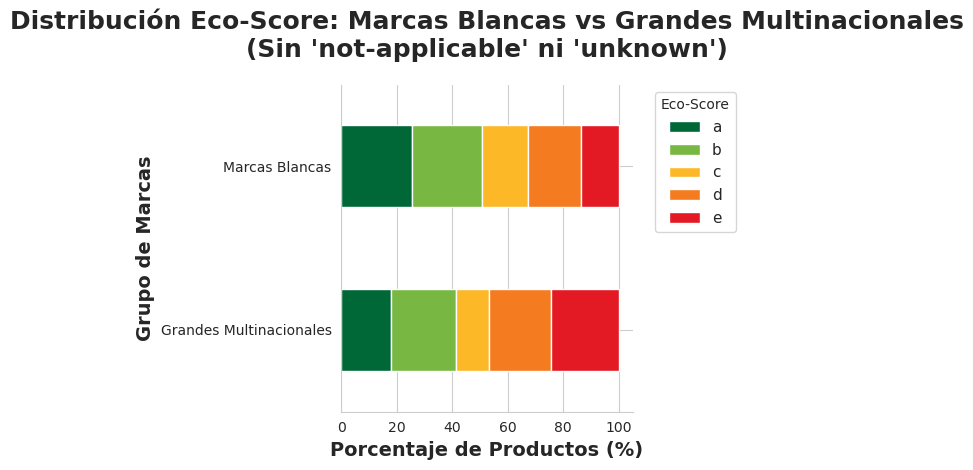

PRODUCTOS VÁLIDOS PARA ECO-SCORE (sin not-applicable/unknown):
grupo
Marcas Blancas             970
Grandes Multinacionales    602
Name: count, dtype: int64

Total productos analizados: 1572

DISTRIBUCIÓN PORCENTUAL DEL ECO-SCORE:
ecoscore_grade              a     b     c     d     e
grupo                                                
Grandes Multinacionales  17.8  23.4  12.1  22.3  24.4
Marcas Blancas           25.4  25.3  16.8  19.0  13.6

📊 COMPARATIVA RÁPIDA:

Marcas Blancas:
  ✅ Eco-Score A (mejor): 25.4%
  ⚠️ Eco-Score E (peor): 13.6%
  🌱 A+B (buen desempeño ambiental): 50.6%

Grandes Multinacionales:
  ✅ Eco-Score A (mejor): 17.8%
  ⚠️ Eco-Score E (peor): 24.4%
  🌱 A+B (buen desempeño ambiental): 41.2%


In [8]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Listas de grupos
marcas_blancas = [
    'hacendado', 'mercadona', 'deliplus', 'compy', 'bosque verde', 'entrepinares', 
    'lidl', 'alesto', 'milbona', 'fin carré', 'sondey', 'freshona', 'crownfield', 
    'carrefour', 'u bio', 'paturages', 'nos regions ont du talent',
    'bio village', 'marque repère',
    'aldi', 'harvest morn', 'village bakery',
    'tesco', 'auchan', 'intermarche'
]

grandes_multinacionales = [
    'nestle', 'nescafe', 'unilever', 'hellmann', 'knorr', 'mondelez', 'lu', 'milka', 
    'danone', 'activia', 'ferrero', 'nutella', 'pepsico', 'lays', 'coca-cola', 
    'kellogg', 'pringles', 'heinz', 'mars', 'dr. oetker'
]

# 2. Clasificar
foods['brands_clean'] = foods['brands'].fillna('').astype(str).str.lower()
def clasificar_grupo(brand):
    brands_list = brand.split()
    for b in brands_list:
        if any(mb in b for mb in marcas_blancas):
            return 'Marcas Blancas'
        if any(multi in b for multi in grandes_multinacionales):
            return 'Grandes Multinacionales'
    return 'Otras'

foods['grupo'] = foods['brands_clean'].apply(clasificar_grupo)

# 3. Filtrar: QUITAR not-applicable, unknown + datos válidos de ECO-SCORE
df_plot = foods[
    (foods['ecoscore_grade'].notna()) &
    (foods['ecoscore_grade'].isin(['a', 'b', 'c', 'd', 'e'])) &  # Solo grados válidos
    (foods['grupo'].isin(['Marcas Blancas', 'Grandes Multinacionales']))
].copy()

# 4. % distribución ECO-SCORE
eco_dist = df_plot.groupby(['grupo', 'ecoscore_grade']).size().unstack(fill_value=0)
eco_pct = eco_dist.div(eco_dist.sum(axis=1), axis=0) * 100

# 5. BAR PLOT
plt.figure(figsize=(12, 8))
sns.set_style("whitegrid")

# Colores para Eco-Score (verde oscuro a rojo, similar a Nutri-Score pero tonos más ecológicos)
colors_eco = {'a': '#006837', 'b': '#78B842', 'c': '#FDB827', 'd': '#F47B20', 'e': '#E31A23'}
eco_order = ['a', 'b', 'c', 'd', 'e']

# Asegurar que todas las categorías existan en eco_pct
for col in eco_order:
    if col not in eco_pct.columns:
        eco_pct[col] = 0

eco_pct[eco_order].plot(kind='barh', stacked=True, color=[colors_eco[col] for col in eco_order])

plt.title("Distribución Eco-Score: Marcas Blancas vs Grandes Multinacionales\n(Sin 'not-applicable' ni 'unknown')", 
          fontsize=18, fontweight='bold', pad=20)
plt.xlabel("Porcentaje de Productos (%)", fontsize=14, fontweight='bold')
plt.ylabel("Grupo de Marcas", fontsize=14, fontweight='bold')
plt.legend(title="Eco-Score", bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=11)
plt.xticks(rotation=0)
sns.despine()
plt.tight_layout()
plt.show()

# Resumen
print("=" * 60)
print("PRODUCTOS VÁLIDOS PARA ECO-SCORE (sin not-applicable/unknown):")
print("=" * 60)
print(df_plot['grupo'].value_counts())
print(f"\nTotal productos analizados: {len(df_plot)}")
print("\n" + "=" * 60)
print("DISTRIBUCIÓN PORCENTUAL DEL ECO-SCORE:")
print("=" * 60)
print(eco_pct.round(1))

# Estadísticas adicionales
print("\n" + "=" * 60)
print("📊 COMPARATIVA RÁPIDA:")
print("=" * 60)

for grupo in ['Marcas Blancas', 'Grandes Multinacionales']:
    if grupo in eco_pct.index:
        print(f"\n{grupo}:")
        print(f"  ✅ Eco-Score A (mejor): {eco_pct.loc[grupo].get('a', 0):.1f}%")
        print(f"  ⚠️ Eco-Score E (peor): {eco_pct.loc[grupo].get('e', 0):.1f}%")
        
        # Suma de A+B (buenos)
        buen_eco = eco_pct.loc[grupo].get('a', 0) + eco_pct.loc[grupo].get('b', 0)
        print(f"  🌱 A+B (buen desempeño ambiental): {buen_eco:.1f}%")

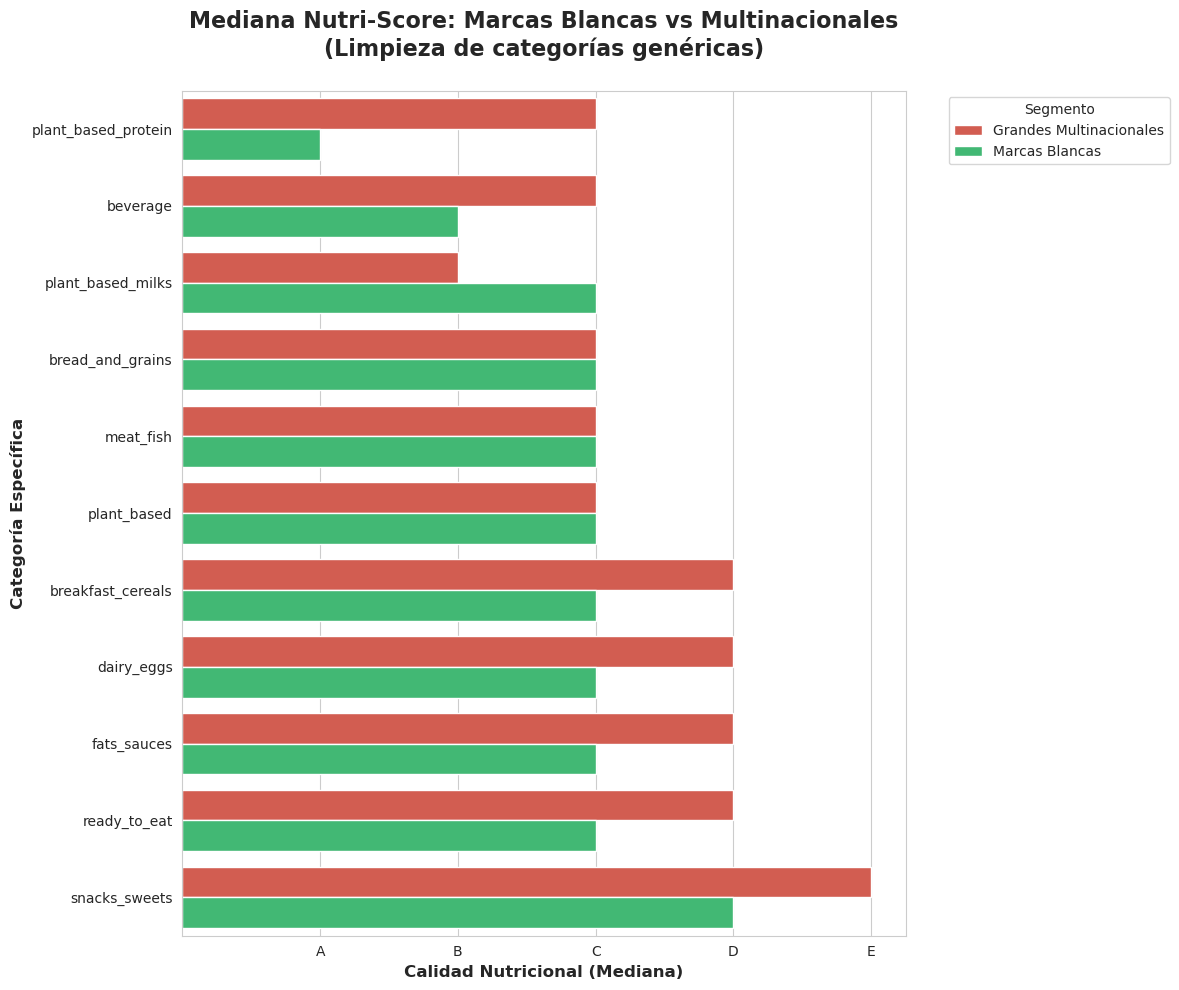

In [14]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Mapeo de Nutri-Score
mapping = {'a': 1, 'b': 2, 'c': 3, 'd': 4, 'e': 5}

# 2. Filtrado Exhaustivo
# - Solo grados válidos (A-E)
# - Solo los dos grupos de interés (excluye el grupo 'Otras')
# - EXCLUIMOS la categoría 'otros' del eje vertical (category_unified)
palabras_a_excluir = ['otros']

df_filtered = foods[
    (foods['nutriscore_grade'].notna()) & 
    (foods['nutriscore_grade'].str.lower().isin(['a', 'b', 'c', 'd', 'e'])) &
    (foods['grupo'].isin(['Marcas Blancas', 'Grandes Multinacionales'])) &
    (~foods['category_unified'].str.lower().str.contains('|'.join(palabras_a_excluir)))
].copy()

# 3. Transformación numérica
df_filtered['nutri_num'] = df_filtered['nutriscore_grade'].str.lower().map(mapping)

# 4. Cálculo de la mediana por categoría y grupo
medianas = df_filtered.groupby(['category_unified', 'grupo'])['nutri_num'].median().reset_index()

# 5. Ordenamos las categorías (por el promedio de sus medianas) para el gráfico
orden_cats = medianas.groupby('category_unified')['nutri_num'].mean().sort_values().index

# 6. Gráfico
plt.figure(figsize=(12, 10))
sns.set_style("whitegrid")

sns.barplot(
    data=medianas, 
    y='category_unified', 
    x='nutri_num', 
    hue='grupo',
    order=orden_cats,
    palette={'Marcas Blancas': '#2ecc71', 'Grandes Multinacionales': '#e74c3c'}
)

# Sustituimos números por letras en el eje X
plt.xticks(ticks=[1, 2, 3, 4, 5], labels=['A', 'B', 'C', 'D', 'E'])

plt.title("Mediana Nutri-Score: Marcas Blancas vs Multinacionales\n(Limpieza de categorías genéricas)", 
          fontsize=16, fontweight='bold', pad=25)
plt.xlabel("Calidad Nutricional (Mediana)", fontsize=12, fontweight='bold')
plt.ylabel("Categoría Específica", fontsize=12, fontweight='bold')
plt.legend(title="Segmento", bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()